# 4.데이터분석_이변량_범주(숫자) vs 범주

## 4.1.환경준비

**1) 라이브러리 불러오기**

In [1]:
import pandas as pd
import numpy as np
import random as rd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

**1) 데이터 불러오기**
- 타이타닉 생존자 : titanic.csv  


In [2]:
titanic = pd.read_csv('data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4.2.범주 --> 범주

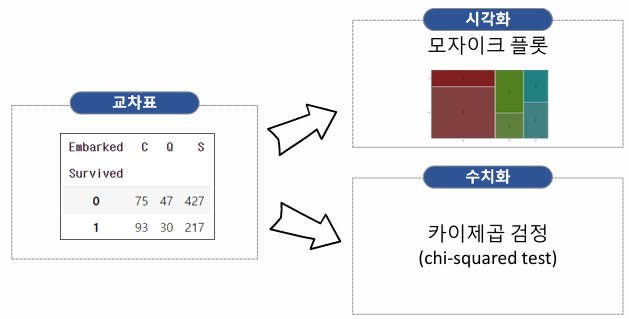

### 4.2.1. 교차표(pd.crosstab)

- 범주 vs 범주 를 비교하고 분석하기 위해서는 먼저 **교차표**를 만들어야 한다.

- pd.crosstab(행, 열)

- `pd.crosstab(행, 열, normalize =   )`
    - normalize: 비율로 계산
    - 행 기준: 각 범주 내 분포를 분석할 때 유용
    - 열 기준: 변수 간 비교를 통해 특정 범주 내 다른 변수의 비율을 볼 때 유용


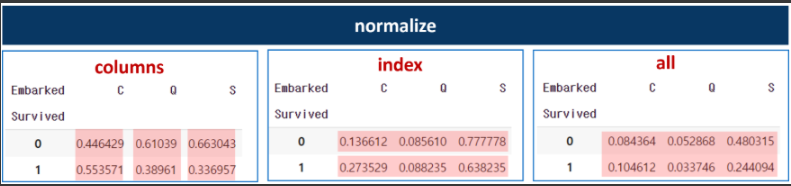

### 4.2.2. 시각화
- mosaic
- 100% Stacked Bar


1) Pclass --> Survived

- mosaic plot
    - `mosaic(dataframe, [ feature, target])`
    - 범주형 변수 간의 비율과 분포를 시각적으로 나타내는 그래프
    - 교차표의 형태를 그림으로 표현하며, 각 사각형의 크기와 길이는 데이터의 비율을 나타냄

① X축 길이는 각 객실등급별 승객비율을 나타낸다.

② 그 중 3등급 객실에 대해서 보면, y축의 길이는, 3등급 객실 승객 중에서 사망, 생존 비율을 의미한다.

- 100% Stacked Bar
    - 먼저 crosstab으로 집계 : `pd.crosstab(feature, target, normalize = 'index')`
    - `.plot.bar(stacked = true)`
    - 전체 평균선 : `plt.axhline()`

- 비율만 비교하므로 양에 대한 비교는 할 수 없다!

**<연습문제>**

- 아래 관계에 대해서 교차표와 시각화(mosaic)를 수행하고, feature와 target 간에 관계가 있는지 분석해 봅시다.


In [ ]:
titanic.head()

[문1] Sex --> Survived

[문2] Embarked --> Survived

[문3] Title --> Survived

### 4.2.3. 수치화 : 카이제곱검정

* 카이제곱검정 : 범주형 변수들 사이에 어떤 관계가 있는지, 수치화 하는 방법

- 카이 제곱 통계량
    - 계산 목적: 관측값(실제 데이터)과 기대값(관계가 없다고 가정했을 때의 값)의 차이를 측정하여, 두 범주형 변수 사이에 연관성이 있는지 확인함.
    - 클수록 기대빈도로부터 실제 값에 차이가 크다는 의미.
    - 계산식으로 볼 때, 범주의 수가 늘어날 수록 값은 커지게 되어 있음.
    - 보통, 자유도의 2~3배 보다 크면, 차이가 있다고 본다.

- 범주형 변수의 자유도 : 범주의 수 - 1

- 카이제곱검정에서는
    - x 변수의 자유도 × y 변수의 자유도
    - 예 : Pclass --> Survived
        - Pclass : 범주가 3개, Survived : 2개
        - (3-1) * (2-1) = 2
        - 그러므로, 2의 2 ~ 3배인 4 ~ 6 보다 카이제곱 통계량이 크면, 차이가 있다고 볼수 있음.


- 자유도 : https://blog.minitab.com/en/statistics-and-quality-data-analysis/what-are-degrees-of-freedom-in-statistics

* 타이타닉 데이터에서 객실등급과 생존여부 간의 카이제곱 검정을 수행해 봅시다.

**<연습문제>**

다음의 관계에 대해 수치화 해 봅시다.

[문1] Sex --> Survived

[문2] Embarked --> Survived

[문3] Title --> Survived

## 4.3.숫자 --> 범주

### 4.3.1. 시각화

- 시각화 : kde Plot, Histogram
    - 범주별 **분포**로 비교하는 그래프 그리기
    - 범주별 **비율**로 비교하는 그래프 그리기

* 히스토그램을 Survived로 나눠서 그려봅시다.

- kdeplot을 그리는 두 가지 방법이 있다.
    - ① kdeplot(   , hue = 'Survived')
        - 생존여부의 비율이 유지된 채로 그려짐
        - 두 그래프의 아래 면적의 합이 1
    - ② kdeplot(   , hue = 'Survived', common_norm = False)
        - 생존여부 각각 아래 면적의 합이 1인 그래프
    - ③ kdeplot(   , hue = 'Survived', multiple = 'fill')
        - 나이에 따라 생존여부 **비율**을 비교해볼 수 있음. (양의 비교가 아닌 비율!)


① kdeplot( , hue = 'Survived)
- common_norm = True (기본값)
    - common_norm: 그래프 안쪽 넓이가 True면 합쳐서 1, 아니면 각각 넓이가 1

② kdeplot( , hue = 'Survived, common_norm = False)

③ multiple = 'fill' 옵션

- 나이에 따라서 생존여부가
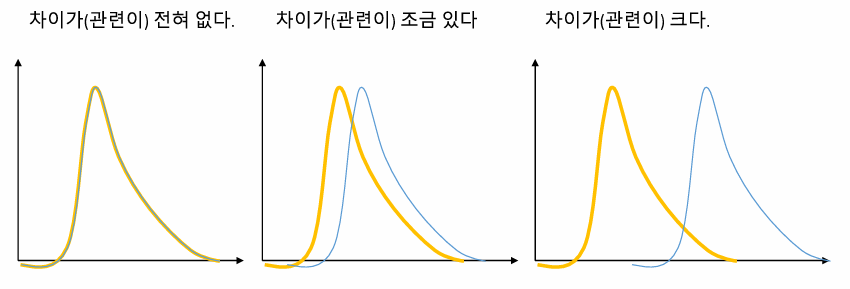

**<연습문제>**

다음의 관계에 대해 시각화 해 봅시다.

* [문1] Fare(운임) --> Survived